### Kernel Trick in SVM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

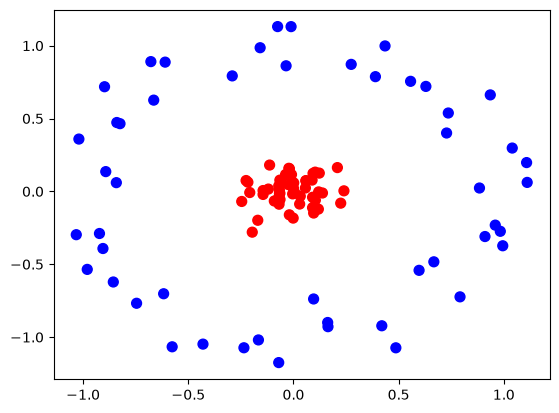

In [3]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [5]:
classifier = SVC(kernel = "linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.35

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define colors for the two classes
zero_one_colourmap = ListedColormap(('blue', 'red'))


def plot_decision_boundary(X, y, clf):
    
    # Store the input features and target values
    X_set, y_set = X, y

    # Create a grid of points covering the entire feature space
    # X1 represents values for the first feature
    # X2 represents values for the second feature
    X1, X2 = np.meshgrid(
        np.arange(
            start=X_set[:, 0].min() - 1,
            stop=X_set[:, 0].max() + 1,
            step=0.01
        ),
        np.arange(
            start=X_set[:, 1].min() - 1,
            stop=X_set[:, 1].max() + 1,
            step=0.01
        )
    )

    # Predict the class for every point in the grid
    # ravel() converts the grid into a 1D array
    # np.array(...).T creates a 2D array of [X1, X2] coordinates
    # reshape() converts predictions back into the grid shape
    predictions = clf.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape)

    # Fill the background according to the predicted class
    # This creates the decision regions
    plt.contourf(
        X1,
        X2,
        predictions,
        alpha=0.75,
        cmap=zero_one_colourmap
    )

    # Set the limits of the X and Y axes
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())

    # Plot the actual data points
    # np.unique(y_set) gives the different classes
    for i, j in enumerate(np.unique(y_set)):

        # Select data points belonging to class j
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            c=[zero_one_colourmap(i)],
            label=j
        )

    # Add title and axis labels
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')

    # Display the legend
    plt.legend()

    # Display the final plot
    return plt.show()

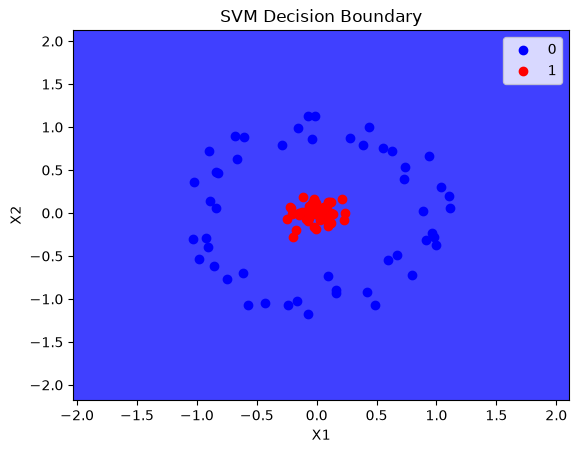

In [9]:
plot_decision_boundary(X, y, classifier)

#### Convert 2D data into 3D data

In [10]:
def plot_3d_plot(X, y):
    # We are using 'r' which is a radial function used for converting 2D data into 3D data
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

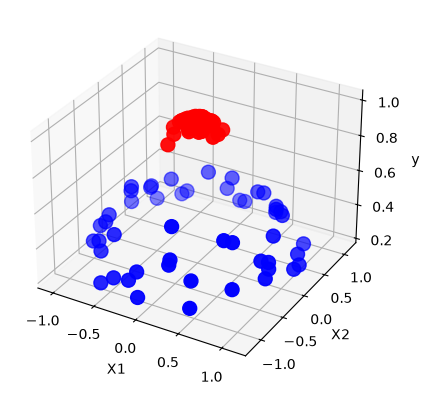

In [11]:
plot_3d_plot(X, y)

In [12]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [13]:
accuracy_score(y_test, y_pred)

1.0

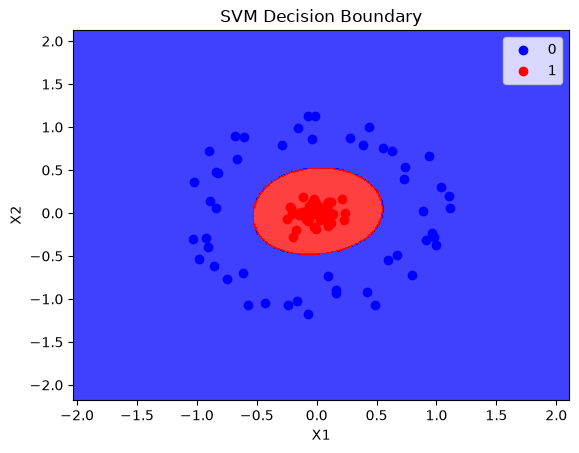

In [14]:
plot_decision_boundary(X, y, rbf_classifier)

In [15]:
poly_classifier = SVC(kernel="poly")
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [16]:
accuracy_score(y_test, y_pred)

0.5

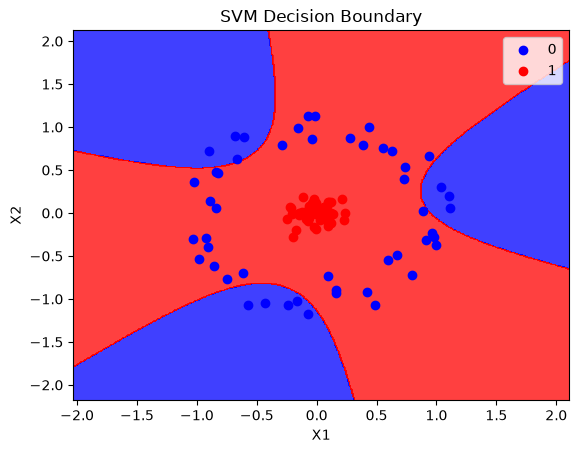

In [17]:
plot_decision_boundary(X, y, poly_classifier)

In [18]:
X

array([[ 8.84345492e-01,  2.32037602e-02],
       [ 1.03331063e-01,  1.32070281e-01],
       [-2.35370715e-01, -1.07302999e+00],
       [ 1.32920240e-03,  5.86483099e-02],
       [ 1.64194275e-01, -9.28299155e-01],
       [-6.64169619e-01,  6.26191150e-01],
       [ 7.91839302e-01, -7.23617944e-01],
       [ 5.86679790e-02,  7.32734114e-02],
       [-1.69588162e-01, -1.98107034e-01],
       [ 7.36133778e-01,  5.37875672e-01],
       [-2.07684462e-01, -7.80067476e-03],
       [ 9.35700985e-01,  6.62151006e-01],
       [ 1.19800854e-01, -3.44909958e-03],
       [-6.65584408e-02, -1.49977789e-02],
       [-2.16529649e-01,  6.30988441e-02],
       [ 8.86587359e-02,  7.76352855e-02],
       [-2.47058028e-02,  4.69103700e-02],
       [-7.51720255e-02,  1.13082443e+00],
       [ 6.04606262e-02,  7.33090720e-02],
       [-4.30035455e-01, -1.04792062e+00],
       [-9.80156239e-01, -5.35185348e-01],
       [-8.24511041e-01,  4.64697851e-01],
       [ 2.74571265e-01,  8.71562840e-01],
       [-3.

In [19]:
np.exp(-(X**2)).sum(1)

array([1.45692122, 1.97208817, 1.26230311, 1.99656452, 1.39582712,
       1.31894085, 1.12655745, 1.99120938, 1.93316326, 1.33042606,
       1.95772331, 1.06167785, 1.98573836, 1.99535486, 1.95022349,
       1.98616133, 1.99719165, 1.2727463 , 1.99099138, 1.16465364,
       1.13356719, 1.31248932, 1.39522565, 1.47459769, 1.29398899,
       1.99969665, 1.2784461 , 1.25999598, 1.98103704, 1.99987516,
       1.97137991, 1.29397694, 1.97934921, 1.98560341, 1.26796652,
       1.99570418, 1.97470247, 1.24165688, 1.99787253, 1.99622141,
       1.1050114 , 1.32655413, 1.99291681, 1.96897671, 1.99137417,
       1.98562265, 1.45250205, 1.99014276, 1.99950953, 1.12824233,
       1.25432689, 1.9898874 , 1.35365028, 1.03799908, 1.14475492,
       1.43291589, 1.98744346, 1.9789439 , 1.25440341, 1.99288972,
       1.30802895, 1.99543704, 1.99369577, 1.97618149, 1.39717378,
       1.26558577, 1.97934174, 1.93096406, 1.34727255, 1.44573128,
       1.43230114, 1.29807916, 1.24672534, 1.34617887, 1.29867

In [20]:
X_new = np.exp(-(X**2))

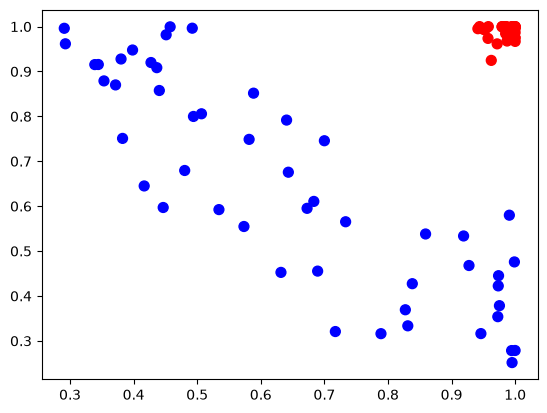

In [21]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')